## Requirements

In [87]:
# !pip3 install geopy
# !pip3 install pandas
# !pip3 install numpy

# Libraries

In [88]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px


sns.set_style('darkgrid')

import warnings 
warnings.filterwarnings("ignore")

# Get The Data

In [89]:
pniot = pd.read_csv("Random_Pniot.csv")
pniot.head()

,תאריך הפניה,שעת הפניה,גיל,מגדר,איזור,ישוב
0,20-03-25,12:07,---,נקבה,תל אביב,תל אביב-יפו
1,20-03-25,12:41,---,נקבה,צפון,חיפה
2,07-10-23,07:45,2,נקבה,צפון,חיפה
3,07-10-23,08:24,---,---,---,---
4,07-10-23,08:47,---,---,דרום,נתיבות


In [90]:
pniot.shape

(24790, 6)

In [91]:
pniot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24790 entries, 0 to 24789
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   תאריך הפניה  24790 non-null  object
 1   שעת הפניה    24790 non-null  object
 2   גיל          24790 non-null  object
 3   מגדר         24790 non-null  object
 4   איזור        24790 non-null  object
 5   ישוב         24790 non-null  object
dtypes: object(6)
memory usage: 1.1+ MB


In [92]:
cities_geo = pd.read_csv("cities_geometric.csv")
cities_geo.head(1)

,city,latitude,longitude
0,תל אביב-יפו,32.0853,34.781806


## Data Cleaning

#### Rename columns

In [93]:
pniot.rename(columns={'תאריך הפניה': 'date',
                      'שעת הפניה': 'time',
                      'גיל': 'age',
                      'מגדר': 'gender',
                      'איזור': 'region',
                      'ישוב': 'city'}, inplace=True)
pniot.head(1)

,date,time,age,gender,region,city
0,20-03-25,12:07,---,נקבה,תל אביב,תל אביב-יפו


In [94]:
pniot['date'] = pd.to_datetime(pniot['date'])
pniot['time'] = pd.to_datetime(pniot['time']).dt.time
pniot.head(3)

,date,time,age,gender,region,city
0,2025-03-20,12:07:00,---,נקבה,תל אביב,תל אביב-יפו
1,2025-03-20,12:41:00,---,נקבה,צפון,חיפה
2,2023-07-10,07:45:00,2,נקבה,צפון,חיפה


#### Check for null values

In [95]:
pniot.replace('---', np.nan, inplace=True)
pniot['city'].replace('לא נמסר', np.nan, inplace=True)

In [96]:
pniot.isnull().sum()

date         0
time         0
age       6657
gender    1106
region    8228
city      9632
dtype: int64

In [97]:
pniot = pniot.dropna(subset=['city'])

In [98]:
pniot.isnull().sum()

date         0
time         0
age       3536
gender      65
region       0
city         0
dtype: int64

In [106]:
pniot_with_geo = pniot.merge(cities_geo, on='city', how='left')
pniot_with_geo.head(1)

,date,time,age,gender,region,city,latitude,longitude
0,2025-03-20,12:07:00,NaN,נקבה,תל אביב,תל אביב-יפו,32.0853,34.781806


### Exploratory Data Analysis - visualization

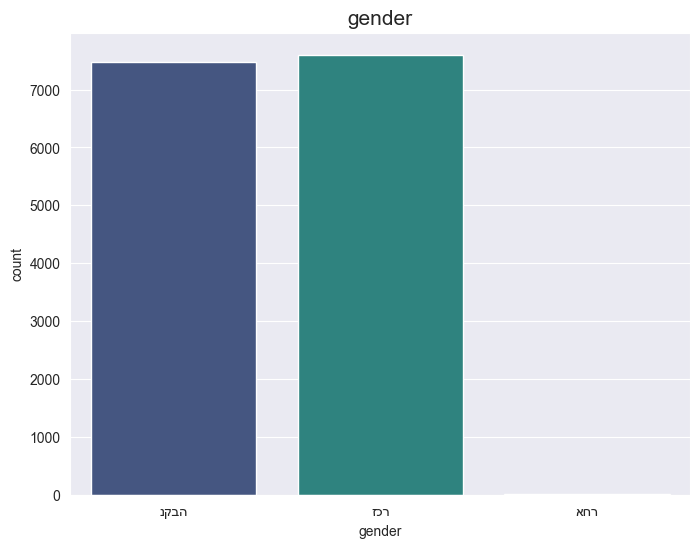

In [100]:
plt.figure(figsize=(8,6))
sns.countplot(x=pniot['gender'], palette='viridis');
plt.title("gender",fontsize=15);

In [101]:
city_count = pniot['city'].value_counts().reset_index()
city_count.columns = ['city', 'count']
city_count.head()

,city,count
0,תל אביב-יפו,1352
1,אשקלון,768
2,ירושלים,763
3,חיפה,612
4,באר שבע,581


### Geographical Plotting

In [119]:
city_counts = pniot_with_geo.groupby(["city", "latitude", "longitude"]).size().reset_index(name="count")
city_counts.head(1)

,city,latitude,longitude,count
0,אבו סנאן,32.958648,35.17166,4


In [126]:
fig = px.scatter_mapbox(
    city_counts,
    lat=city_counts["latitude"],
    lon=city_counts["longitude"],
    size=city_counts["count"],
    color=city_counts["count"],
    hover_name=city_counts["city"],
    color_continuous_scale='Turbo',
    zoom=6,
    height=600,
    width=450,
    mapbox_style="open-street-map"
)

fig.show()